# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [194]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from underthesea import word_tokenize
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [195]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [196]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [197]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [198]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [199]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**


In [200]:
file = os.path.join("../../Data_Train", "English.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [201]:
data_df.head(5)

,title,text,label
0,As U.S. budget fight looms Republicans flip th...,WASHINGTON (Reuters) - The head of a conservat...,0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,0
2,Senior U.S. Republican senator: Let Mr. Muelle...,WASHINGTON (Reuters) - The special counsel inv...,0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,0
4,Trump wants Postal Service to charge much more...,SEATTLE/WASHINGTON (Reuters) - President Donal...,0


**Xáo trộn dữ liệu**

In [202]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [203]:
data_df.head(5)

,title,text,label
0,McCain presses U.S. Air Force Pentagon over Ru...,WASHINGTON (Reuters) - The head of the U.S. Se...,0
1,Fiscal Conservative Ted Cruz Just Released His...,If you ever want to know how STUPID Republican...,1
2,SAY WHAT? Trump-Hater RINO John McCain Admits ...,Sworn Donald Trump enemy John McCain admitted ...,1
3,CATHOLIC BISHOP OUTRAGED Over Hillary’s ANTI-C...,Hillary s been using churches across America a...,1
4,U.S. suspends Obama airline transparency review,WASHINGTON (Reuters) - The Trump administratio...,0


**Mô tả của dữ liệu**

In [101]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39000 entries, 0 to 38999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   39000 non-null  object
 1   text    39000 non-null  object
 2   label   39000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 914.2+ KB


In [102]:
data_df.describe().round(1)

,label
count,39000.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


**Kích thước của DataFrame và danh sách các tên cột**

In [103]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(39000, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [104]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

39000
3


**Kiểm tra dữ liệu có bị lặp**

In [105]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [106]:
data_df['title'].isnull().sum()

0

In [107]:
data_df['text'].isnull().sum()

0

In [108]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [109]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [110]:
open_object_dtype(data_df['title'])

{str}

In [111]:
open_object_dtype(data_df['text'])

{str}

In [112]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [113]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [114]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,39000.000000,39000.000000
mean,12.573256,405.981795
std,4.075220,283.286978
min,1.000000,19.000000
25%,10.000000,230.000000
50%,12.000000,372.000000
75%,14.000000,516.000000
max,42.000000,7033.000000


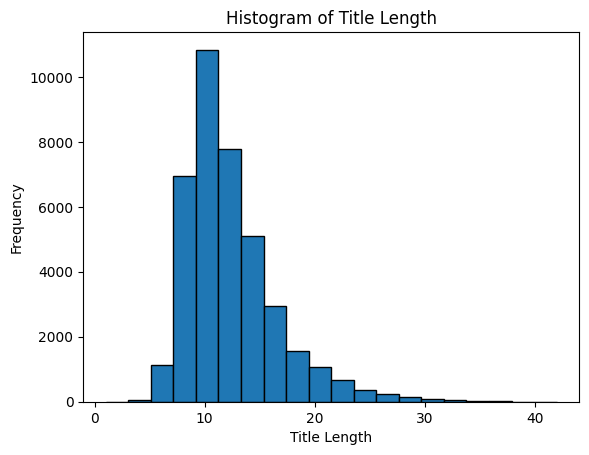

In [115]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

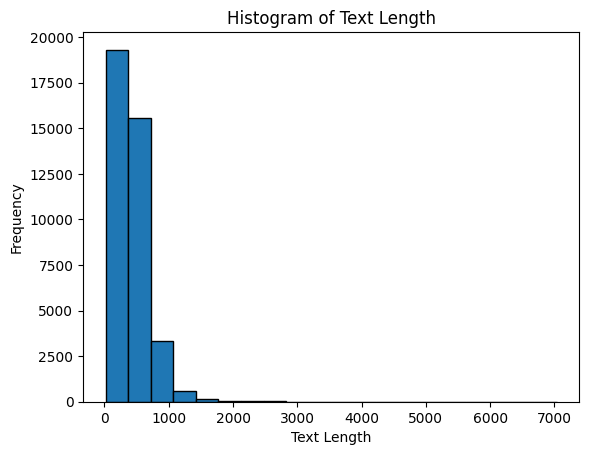

In [116]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

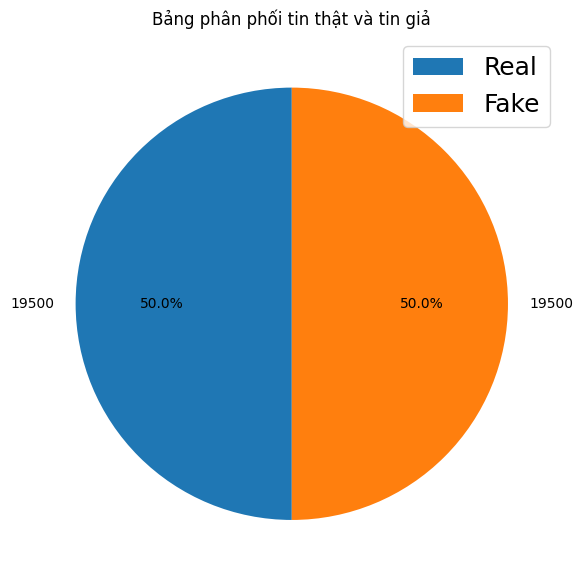

In [117]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [118]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

12.573717948717949

**Độ dài lớn nhất của tiêu đề**

In [119]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

42

**Độ dài nhỏ nhất của tiêu đề**

In [120]:
min_title_len=max_title_len

for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [121]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

405.9954358974359

**Độ dài lớn nhất của text**

In [122]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

7033

**Độ dài nhỏ nhất của text**

In [123]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

19

**Tổng số từ trong title**

In [124]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

490375

**Tổng số từ trong text**

In [125]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

15833822

**Số từ khác biệt trong title**

In [126]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

43603

**Số từ khác biệt trong text**

In [127]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

303458

# Tiền xử lí văn bản

**Tạo stopword**

In [128]:
import nltk
from nltk.corpus import stopwords

# Tải stopwords từ NLTK nếu chưa tải
# nltk.download('stopwords')

# Sử dụng danh sách từ dừng (stopwords) của tiếng Anh từ NLTK
stopword_list = list(stopwords.words('english'))
stopwords = [word for word in stopword_list if word.strip() != '']


**Loại bỏ các đường link và các dấu câu, lowercase**

In [129]:
import string
def wordopt(text):
    text=re.sub("Reuters"," ",text)

    update_text =""

    text = text.lower()

    text=re.sub("reuters"," ",text)
    
    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)


    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('\\W', ' ', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()

    for word in text.split():
        if word not in stopwords:
            update_text += word+" "
    
    return update_text.strip()


**Hợp nhất title và text**

In [130]:
data_df['article'] = data_df["title"] +  data_df["text"] 

In [131]:
data_df.head(1)

,title,text,label,title_length,text_length,article
0,As U.S. budget fight looms Republicans flip th...,WASHINGTON (Reuters) - The head of a conservat...,0,10,750,As U.S. budget fight looms Republicans flip th...


**Áp dụng các xử lý dữ liệu**

In [132]:
data_df['Compound_Content_SW'] = data_df['article'].apply(wordopt)

In [133]:
data_df.head(1)

,title,text,label,title_length,text_length,article,Compound_Content_SW
0,As U.S. budget fight looms Republicans flip th...,WASHINGTON (Reuters) - The head of a conservat...,0,10,750,As U.S. budget fight looms Republicans flip th...,u budget fight looms republicans flip fiscal s...


**Tổng số từ**

In [134]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

9400136

**Số từ khác biệt còn lại**

In [135]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

116329

**Xác định tần suất xuất hiện các từ trong từng tài liệu**

In [136]:
from collections import Counter

In [137]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [138]:
print(len(total_word_counts))
for word, count in total_word_counts.most_common():
    print(f"{word}: {count/len(data_df)}")


116329
said: 0.7629230769230769
president: 0.5576410256410257
trump: 0.5386923076923077
would: 0.5325384615384615
one: 0.47125641025641024
people: 0.446025641025641
donald: 0.44466666666666665
u: 0.4336923076923077
also: 0.42730769230769233
new: 0.3628461538461539
told: 0.3488974358974359
could: 0.3323076923076923
last: 0.32743589743589746
state: 0.3243846153846154
year: 0.324025641025641
time: 0.32369230769230767
like: 0.31364102564102564
two: 0.3129487179487179
states: 0.3087948717948718
house: 0.3062051282051282
first: 0.28994871794871796
republican: 0.28917948717948716
government: 0.28535897435897434
united: 0.2751794871794872
via: 0.27453846153846156
even: 0.27087179487179486
country: 0.2615897435897436
made: 0.2611794871794872
white: 0.25861538461538464
say: 0.25243589743589745
make: 0.25135897435897436
news: 0.2502051282051282
many: 0.2501025641025641
former: 0.2475897435897436
years: 0.24702564102564104
since: 0.24297435897435898
get: 0.24061538461538462
campaign: 0.23871794871

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [139]:
def tokenize(sentence):
    return word_tokenize(sentence)

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [140]:
X = data_df["Compound_Content_SW"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [141]:
# model_vector_CV = os.path.join("../../Vector/English/CV", "English_vectorizer_CV.joblib")
# model_RFC_CV = os.path.join("../../Vector/English/CV", "English_RFC_model_CV.joblib")


In [142]:
model_vector_TF = os.path.join("../../Vector/English", "English_vectorizer_TF.joblib")
# model_RFC_TF = os.path.join("../../Vector/English/TF", "English_RFC_model_TF.joblib")

In [143]:
# model_vector_W2V = os.path.join("../../Vector/English/W2V", "English_vectorizer_W2V.joblib")
# model_RFC_W2V = os.path.join("../../Vector/English/W2V", "English_RFC_model_W2V.joblib")

In [144]:
# model_vector_D2V = os.path.join("../../Vector/English/D2V", "English_vectorizer_D2V.joblib")
# model_RFC_D2V = os.path.join("../../Vector/English/D2V", "English_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [145]:
vectorizerCV = CountVectorizer(max_features=10000,        # Chỉ giữ lại 10,000 từ phổ biến nhất
                                min_df=60,                 # Từ phải xuất hiện ít nhất trong 60 tài liệu
                                max_df=0.5,
                                stop_words=stopwords,  
                                tokenizer = tokenize,
                                ngram_range=(1,3)
                                )

In [146]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [147]:
vectorizerTF = TfidfVectorizer(max_features=10000,        # Chỉ giữ lại 10,000 từ phổ biến nhất
                                min_df=60,                 # Từ phải xuất hiện ít nhất trong 60 tài liệu
                                max_df=0.5,
                                stop_words=stopwords,  
                                tokenizer = tokenize,
                                use_idf=True, 
                                ngram_range=(1,3)
                                )

In [148]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [149]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [150]:
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=10
)

In [151]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

In [152]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [153]:
def preprocess(doc):
    words = word_tokenize(doc)
    return [word for word in words if word not in stopwords]

In [154]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [155]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [156]:
Xv_trainD2V = [vectorizerD2V.infer_vector(preprocess(doc)) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(preprocess(doc)) for doc in X_test]

## Save model

In [157]:
# joblib.dump(vectorizerCV, model_vector_CV)
joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Vector/English\\English_vectorizer_TF.joblib']

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [158]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [159]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [160]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [161]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [162]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [163]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [164]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [165]:
def evaluate_model(y_true, y_pred, name_model, save=False):

    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }
    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/English", f"English_Evaluate_{name_model}.csv")
        
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

**CountVectorizer**

0.9884102564102564
-------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



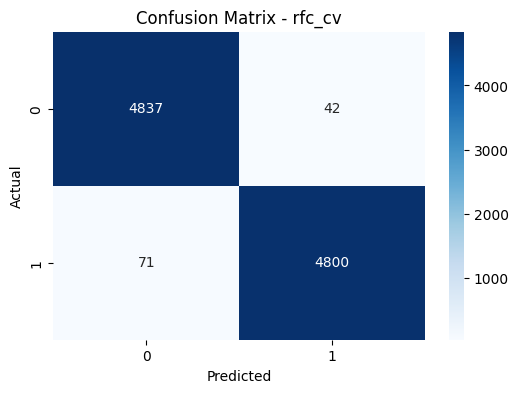

In [166]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv",save=True)

**TfidfVectorizer**

0.9875897435897436
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4879
           1       0.99      0.98      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



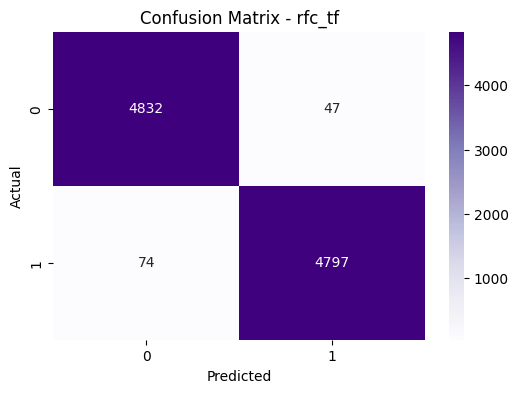

In [167]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf",save=True)

**Word2Vec**

0.9633846153846154
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4879
           1       0.96      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



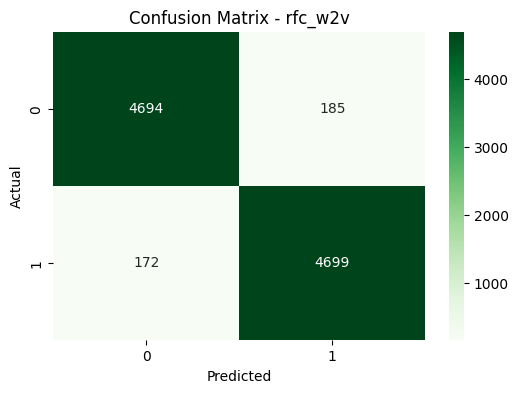

In [168]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v",save=True)


**Doc2Vec**

0.9352820512820513
-------------------

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      4879
           1       0.92      0.95      0.94      4871

    accuracy                           0.94      9750
   macro avg       0.94      0.94      0.94      9750
weighted avg       0.94      0.94      0.94      9750

-------------------



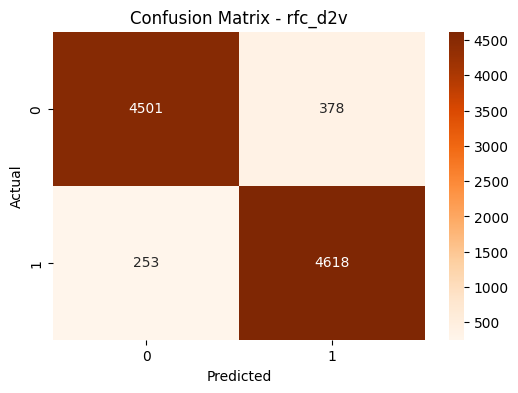

In [169]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v",save=True)

*Save model RFC*

In [170]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [171]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.9511794871794872
-------------------

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4879
           1       0.95      0.95      0.95      4871

    accuracy                           0.95      9750
   macro avg       0.95      0.95      0.95      9750
weighted avg       0.95      0.95      0.95      9750

-------------------



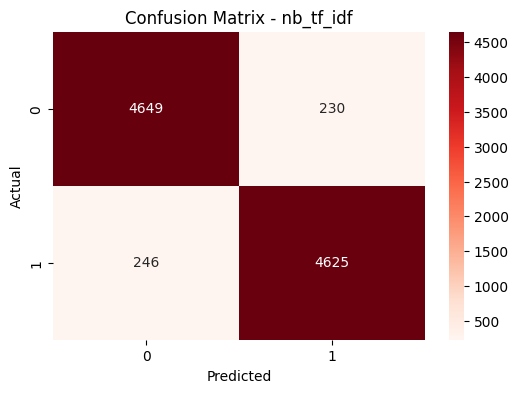

In [172]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf_idf")

## Decision Tree

In [173]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.9605128205128205
-------------------

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      4879
           1       0.95      0.97      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



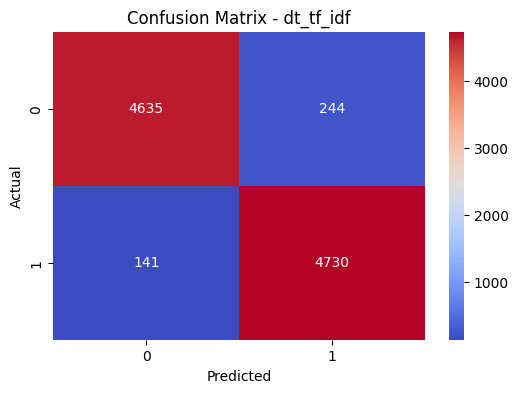

In [174]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf_idf")

## RandomForest

In [175]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.9875897435897436
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4879
           1       0.99      0.98      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



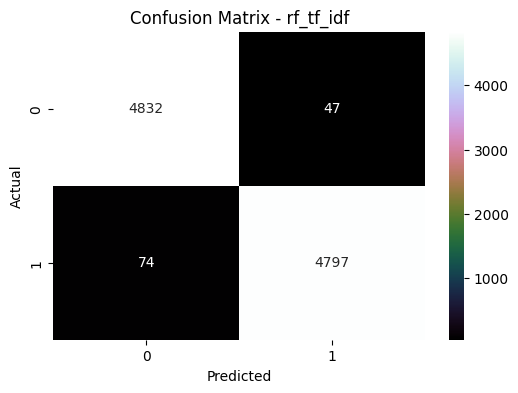

In [176]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf_idf")

## SVM

In [177]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9922051282051282
-------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



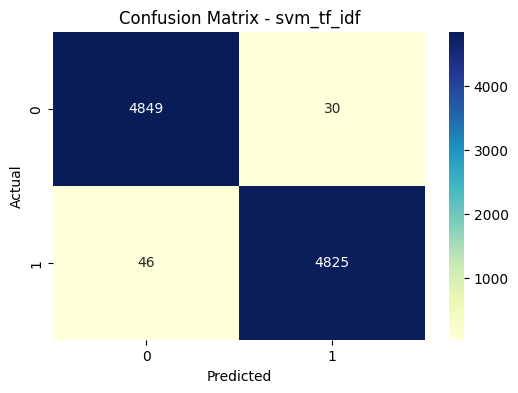

In [178]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf_idf")

In [179]:
model_SVM_TF = os.path.join("../../Vector/English", "English_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/English\\English_SVM_model_TF.joblib']

## LogisticRegression

In [180]:
lr_model = LogisticRegression()
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)


0.9844102564102564
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4879
           1       0.99      0.98      0.98      4871

    accuracy                           0.98      9750
   macro avg       0.98      0.98      0.98      9750
weighted avg       0.98      0.98      0.98      9750

-------------------



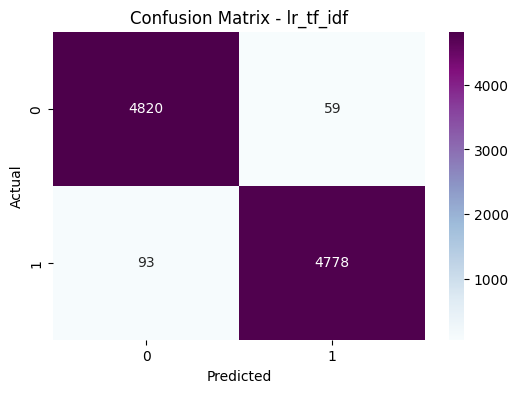

In [181]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf_idf")

## GradientBoostingClassifier

In [182]:
gbc_model = GradientBoostingClassifier(random_state=0)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.964
-------------------

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      4879
           1       0.98      0.95      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



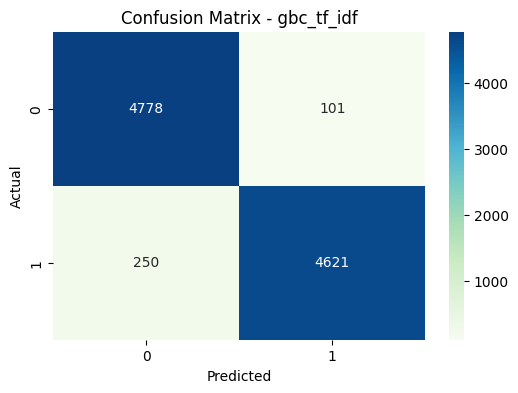

In [183]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf_idf")

**Save**

In [184]:
model_SVM_TF = os.path.join("../../Vector/English", "English_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/English\\English_SVM_model_TF.joblib']